# Market Impact Scenarios and Capacity Analysis

**Docker image**: `ml4t`

This notebook combines literature impact parameters with observed volatility, estimates a
normalized signed-flow association from NASDAQ-100 minute bars, maps intraday volume, and builds
capacity scenarios only where the data support dollar notional.

**Learning Objectives:**
- Parameterize $I = \sigma\eta\sqrt{Q/V}$ without mistaking assumptions for calibration
- Estimate a robust same-minute association from tick-rule signed flow
- Normalize cross-symbol impact and report slope uncertainty
- Distinguish shares, contracts, base volume, tick activity, and dollar notional
- Build bounded capacity scenarios and compare normalized impact-model shapes

**Book Reference:** Chapter 18, Sections 18.3, 18.4, and 18.8

**Prerequisites:** Access to six market panels, VIX, and licensed NASDAQ-100 minute bars with
tick-direction volume fields.

In [1]:
"""Unit-aware market-impact scenarios and capacity analysis."""

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from _cost_analysis import (
    compute_adv,
    estimate_kyle_lambda,
)
from IPython.display import Markdown, display

from data import (
    load_cme_futures,
    load_crypto_perps,
    load_etfs,
    load_fx_pairs,
    load_macro,
    load_nasdaq100_bars,
    load_sp500_daily_bars,
)
from utils.paths import REPO_ROOT
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
MAX_SYMBOLS = 50
SEED = 42
NQ100_SYMBOLS = 100
NQ100_START_DATE = "2021-10-01"
NQ100_END_DATE = "2021-12-31"
VOL_WINDOW = 20
ADV_WINDOW = 20
GROSS_ALPHA_BPS = 50
TURNOVER_PER_REBALANCE = 0.30
MAX_FEASIBLE_PARTICIPATION = 0.20
MODEL_REFERENCE_PARTICIPATION = 0.01

In [3]:
set_global_seeds(SEED)


def add_message_title(ax, message: str, subtitle: str | None = None) -> None:
    """Apply the project message-title style with an available font weight."""
    ax.set_title(
        message,
        loc="left",
        color=COLORS["blue"],
        fontweight="bold",
        pad=15 if subtitle else 8,
    )
    if subtitle:
        ax.annotate(
            subtitle,
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(0, 4),
            textcoords="offset points",
            ha="left",
            va="bottom",
            fontsize=9,
            color=COLORS["neutral"],
        )

## 1. Descriptive Market Panels

The panels below use native volume units. Full-window activity rankings keep the exercise
tractable; they are retrospective sample definitions, not point-in-time universes.

In [4]:
def keep_top_symbols(df: pl.DataFrame, entity_col: str) -> pl.DataFrame:
    """Restrict a descriptive panel to its most active entities."""
    if MAX_SYMBOLS <= 0:
        return df
    top = df.group_by(entity_col).agg(pl.col("volume").mean()).sort("volume", descending=True)
    top_entities = top.head(MAX_SYMBOLS)[entity_col].to_list()
    return df.filter(pl.col(entity_col).is_in(top_entities))

### Rolling Descriptive Features

Rolling volatility and native-unit ADV include the current observation. They summarize the
historical sample; a live same-day decision would lag both features.

In [5]:
def add_impact_features(
    df: pl.DataFrame,
    entity_col: str,
    time_col: str = "timestamp",
) -> pl.DataFrame:
    """Add returns, native-unit ADV, and volatility within each entity."""
    return df.sort([entity_col, time_col]).with_columns(
        ret=pl.col("close").pct_change().over(entity_col),
        adv_native=compute_adv(pl.col("volume"), ADV_WINDOW).over(entity_col),
        sigma=pl.col("close")
        .pct_change()
        .over(entity_col)
        .rolling_std(VOL_WINDOW)
        .over(entity_col),
    )

### ETF and Crypto Panels

ETF adjusted prices and observed share volume cannot reconstruct historical dollar turnover.
Crypto quote turnover is valid only when price times base volume is summed bar by bar.

In [6]:
daily_stats = {}
entity_cols = {}
time_cols = {}
volume_units = {}

etfs = keep_top_symbols(load_etfs(), "symbol")
daily_stats["ETFs"] = add_impact_features(etfs, "symbol")
entity_cols["ETFs"], time_cols["ETFs"] = "symbol", "timestamp"
volume_units["ETFs"] = "shares with adjusted price; no historical USD notional"

crypto = keep_top_symbols(load_crypto_perps(frequency="8h"), "symbol")
crypto_daily = (
    crypto.sort(["symbol", "timestamp"])
    .with_columns(
        activity_date=pl.col("timestamp").dt.date(),
        bar_turnover_usd=pl.col("close") * pl.col("volume"),
    )
    .group_by(["symbol", "activity_date"])
    .agg(
        close=pl.col("close").last(),
        volume=pl.col("volume").sum(),
        daily_turnover_usd=pl.col("bar_turnover_usd").sum(),
    )
    .rename({"activity_date": "timestamp"})
)
daily_stats["Crypto Perps"] = add_impact_features(crypto_daily, "symbol")
entity_cols["Crypto Perps"], time_cols["Crypto Perps"] = "symbol", "timestamp"
volume_units["Crypto Perps"] = "base asset; bar-level conversion to USDT turnover"

### CME Futures Panel

Futures volume counts contracts. Dollar turnover requires the product multiplier, derived from
tick value divided by tick size. Returns use roll-adjusted prices; notional uses raw traded prices.

In [7]:
spec_path = REPO_ROOT / "data" / "futures" / "market" / "futures_specs.yaml"
product_specs = yaml.safe_load(spec_path.read_text())["products"]
multiplier_df = pl.DataFrame(
    [
        {
            "product": product,
            "price_multiplier": float(spec["tick_value"]) / float(spec["tick_size"]),
        }
        for product, spec in product_specs.items()
    ]
)

futures = load_cme_futures(tenors=[0]).rename({"session_date": "timestamp"})
futures = keep_top_symbols(futures, "product").join(
    multiplier_df,
    on="product",
    how="left",
)
missing_multipliers = futures.filter(pl.col("price_multiplier").is_null())["product"].unique()
if len(missing_multipliers) > 0:
    raise ValueError(f"Missing CME multipliers for: {sorted(missing_multipliers.to_list())}")

In [8]:
cme_daily = futures.select(
    "product",
    "timestamp",
    pl.col("adj_close").alias("close"),
    "raw_close",
    "volume",
    "price_multiplier",
).with_columns(
    daily_turnover_usd=pl.col("volume") * pl.col("raw_close") * pl.col("price_multiplier")
)
daily_stats["CME Futures"] = add_impact_features(cme_daily, "product")
entity_cols["CME Futures"], time_cols["CME Futures"] = "product", "timestamp"
volume_units["CME Futures"] = "contracts; multiplier-adjusted USD notional"

### FX and S&P 500 Panels

OANDA volume is tick activity, so FX remains outside dollar-capacity comparisons. S&P 500 bars
pair traded prices with share volume and support row-level dollar turnover.

In [9]:
fx = keep_top_symbols(load_fx_pairs(frequency="daily"), "symbol")
daily_stats["FX Pairs"] = add_impact_features(fx, "symbol")
entity_cols["FX Pairs"], time_cols["FX Pairs"] = "symbol", "timestamp"
volume_units["FX Pairs"] = "OANDA ticks; no traded notional"

sp500 = keep_top_symbols(load_sp500_daily_bars(), "symbol").with_columns(
    daily_turnover_usd=pl.col("close") * pl.col("volume")
)
daily_stats["S&P 500 Equities"] = add_impact_features(sp500, "symbol")
entity_cols["S&P 500 Equities"], time_cols["S&P 500 Equities"] = "symbol", "timestamp"
volume_units["S&P 500 Equities"] = "shares; traded-price USD notional"

### NASDAQ-100 Daily Panel

The loader's default path keeps regular-session bars. Sorting before `last()` makes the daily
close explicit rather than relying on input order.

In [10]:
nq_daily = (
    load_nasdaq100_bars(
        start_date=NQ100_START_DATE,
        end_date=NQ100_END_DATE,
        lazy=True,
    )
    .select("timestamp", "symbol", "close", "volume")
    .sort(["symbol", "timestamp"])
    .with_columns(activity_date=pl.col("timestamp").dt.date())
    .group_by(["symbol", "activity_date"])
    .agg(close=pl.col("close").last(), volume=pl.col("volume").sum())
    .rename({"activity_date": "timestamp"})
    .collect()
    .sort(["symbol", "timestamp"])
)
nq_daily = keep_top_symbols(nq_daily, "symbol").with_columns(
    daily_turnover_usd=pl.col("close") * pl.col("volume")
)
daily_stats["NASDAQ-100"] = add_impact_features(nq_daily, "symbol")
entity_cols["NASDAQ-100"], time_cols["NASDAQ-100"] = "symbol", "timestamp"
volume_units["NASDAQ-100"] = "shares; traded-price USD notional"

### Panel Contract

Different histories and native units prevent a market-wide ranking. This table makes the sample
scope explicit before any scenario is plotted.

In [11]:
panel_summary = pl.DataFrame(
    [
        {
            "market": name,
            "rows": len(df),
            "entities": df[entity_cols[name]].n_unique(),
            "start": df[time_cols[name]].min(),
            "end": df[time_cols[name]].max(),
            "volume_contract": volume_units[name],
            "supports_usd_capacity": "daily_turnover_usd" in df.columns,
        }
        for name, df in daily_stats.items()
    ]
)
panel_summary

market,rows,entities,start,end,volume_contract,supports_usd_capacity
str,i64,i64,date,date,str,bool
"""ETFs""",236266,50,2006-01-03,2025-12-31,"""shares with adjusted price; no…",false
"""Crypto Perps""",36109,19,2020-01-01,2025-12-31,"""base asset; bar-level conversi…",true
"""CME Futures""",113506,30,2011-01-03,2025-12-31,"""contracts; multiplier-adjusted…",true
"""FX Pairs""",77480,20,2011-01-03,2025-12-31,"""OANDA ticks; no traded notiona…",false
"""S&P 500 Equities""",52120,50,2017-01-03,2021-12-31,"""shares; traded-price USD notio…",true
"""NASDAQ-100""",3200,50,2021-10-01,2021-12-31,"""shares; traded-price USD notio…",true


**Interpretation**: These are selected retrospective panels, not equally precise samples. Only
crypto, multiplier-adjusted CME futures, and the two US equity panels carry defensible dollar
turnover for the capacity exercise.

## 2. Square-Root Impact Scenarios

A common institutional baseline maps participation into expected price pressure:

$$\text{Impact} = \sigma \cdot \eta \cdot \sqrt{\frac{Q}{V}}$$

where $\sigma$ is daily volatility, $Q$ is trade size, $V$ is ADV, and
$\eta$ is the impact coefficient.

Calibrating $\eta$ requires execution records. We do not have those records here. The exercise
therefore combines literature starting values with each selected panel's median realized
volatility. It parameterizes a scenario; it does not test the square-root exponent or estimate
eta from these market data.

In [12]:
# Literature starting values for scenario analysis
LITERATURE_ETA = {
    "ETFs": 0.10,
    "S&P 500 Equities": 0.15,
    "NASDAQ-100": 0.12,
    "CME Futures": 0.08,
    "Crypto Perps": 0.30,
    "FX Pairs": 0.05,
}

scenario_rows = []
for name, df in daily_stats.items():
    valid = df.filter(pl.col("sigma").is_not_null() & (pl.col("sigma") > 0))
    med_sigma = valid["sigma"].median()
    if med_sigma is None:
        continue
    eta = LITERATURE_ETA[name]
    scenario_rows.append(
        {
            "market": name,
            "eta_assumption": eta,
            "median_daily_sigma": med_sigma,
            "impact_1pct_bps": med_sigma * eta * np.sqrt(0.01) * 10_000,
            "observations": len(valid),
        }
    )

scenario_df = pl.DataFrame(scenario_rows).sort("impact_1pct_bps")
scenario_df

market,eta_assumption,median_daily_sigma,impact_1pct_bps,observations
str,f64,f64,f64,i64
"""FX Pairs""",0.05,0.004876,0.243821,77080
"""CME Futures""",0.08,0.009335,0.746775,112906
"""ETFs""",0.1,0.010267,1.026656,235266
"""NASDAQ-100""",0.12,0.018579,2.229491,2200
"""S&P 500 Equities""",0.15,0.017563,2.634474,51120
"""Crypto Perps""",0.3,0.044143,13.242851,35634


**Interpretation**: `eta_assumption` is external to the sample. Differences in the table reflect
both that assumption and each selected panel's realized volatility, not empirical proof that one
market has a particular impact law.

### Scenario Curves

/tmp/ipykernel_1437927/231346412.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


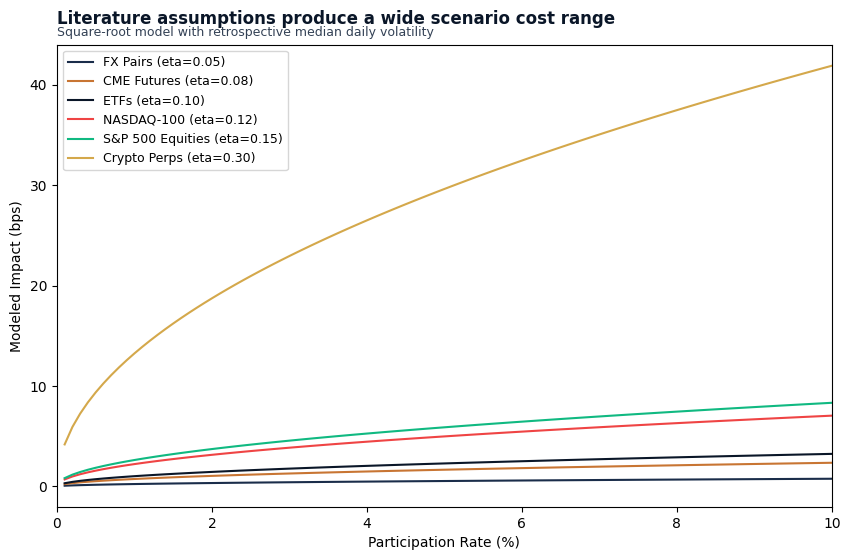

In [13]:
participation_rates = np.linspace(0.001, 0.10, 100)
market_colors = {
    "ETFs": COLORS["blue"],
    "Crypto Perps": COLORS["amber"],
    "CME Futures": COLORS["copper"],
    "FX Pairs": COLORS["slate"],
    "S&P 500 Equities": COLORS["positive"],
    "NASDAQ-100": COLORS["negative"],
}

fig, ax = plt.subplots(figsize=(10, 6))
for row in scenario_df.iter_rows(named=True):
    name = row["market"]
    eta = row["eta_assumption"]
    med_sigma = row["median_daily_sigma"]
    impact_bps = med_sigma * eta * np.sqrt(participation_rates) * 10_000
    ax.plot(
        participation_rates * 100,
        impact_bps,
        color=market_colors[name],
        label=f"{name} (eta={eta:.2f})",
    )

ax.set_xlabel("Participation Rate (%)")
ax.set_ylabel("Modeled Impact (bps)")
add_message_title(
    ax,
    "Literature assumptions produce a wide scenario cost range",
    subtitle="Square-root model with retrospective median daily volatility",
)
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(0, 10)

fig.show()

In [14]:
lowest_scenario = scenario_df.row(0, named=True)
highest_scenario = scenario_df.row(-1, named=True)
display(
    Markdown(
        f"**Scenario reading:** At 1% participation, modeled impact spans "
        f"{lowest_scenario['impact_1pct_bps']:.1f} bps for "
        f"{lowest_scenario['market']} to {highest_scenario['impact_1pct_bps']:.1f} bps for "
        f"{highest_scenario['market']}. This spread is conditional on the literature eta inputs; "
        "it is not a cross-market calibration result."
    )
)

**Scenario reading:** At 1% participation, modeled impact spans 0.2 bps for FX Pairs to 13.2 bps for Crypto Perps. This spread is conditional on the literature eta inputs; it is not a cross-market calibration result.

## 3. Normalized Signed-Flow Association

AlgoSeek reports volume classified by the tick rule. We subtract downtick from uptick volume and
relate that signed flow to the return ending in the same minute:

$$r_t^{bps} = \lambda_{part}\left(10^4\frac{Q_t}{ADV}\right) + \varepsilon_t.$$

Both sides are in basis points, so $\lambda_{part}$ is comparable across nominal stock prices.
Aggregated bars do not reveal whether the signed flow preceded the price move. The coefficient is
a robust contemporaneous association, not a causal impact estimate.

### Restore the Regular Session

Raw microstructure mode bypasses the loader's clock filter. The helper below applies the
documented 09:30 inclusive to 16:00 exclusive window before ranking symbols or fitting slopes.

In [15]:
def regular_session_mask(timestamp_col: str = "timestamp") -> pl.Expr:
    """Return the documented US-equity regular-session mask."""
    hour = pl.col(timestamp_col).dt.hour()
    minute = pl.col(timestamp_col).dt.minute()
    return ((hour > 9) | ((hour == 9) & (minute >= 30))) & (hour < 16)

### Load and Reconcile the Signed-Flow Sample

In [16]:
def session_integrity_ledger(
    raw: pl.DataFrame,
    regular: pl.DataFrame,
    selected: pl.DataFrame,
) -> pl.DataFrame:
    """Reconcile raw, session-filtered, and selected minute rows."""
    unique_keys = selected.select(pl.struct("symbol", "timestamp").n_unique()).item()
    return pl.DataFrame(
        {
            "population": [
                "Raw rows",
                "Outside regular session",
                "Regular rows",
                "Selected rows",
                "Duplicate keys",
            ],
            "rows": [
                len(raw),
                len(raw) - len(regular),
                len(regular),
                len(selected),
                len(selected) - unique_keys,
            ],
        }
    )

In [17]:
def load_nq_signed_flow_sample() -> tuple[pl.DataFrame, pl.DataFrame]:
    """Load a regular-session liquid sample and its row-conservation ledger."""
    raw = load_nasdaq100_bars(
        start_date=NQ100_START_DATE,
        end_date=NQ100_END_DATE,
        include_microstructure=True,
    ).select(
        "timestamp",
        "symbol",
        "volume",
        "last_trade_price",
        "uptick_volume",
        "downtick_volume",
    )
    regular = raw.filter(regular_session_mask())
    n_symbols = NQ100_SYMBOLS if NQ100_SYMBOLS > 0 else regular["symbol"].n_unique()
    top_symbols = (
        regular.group_by("symbol")
        .agg(pl.col("volume").sum())
        .sort("volume", descending=True)
        .head(n_symbols)["symbol"]
        .to_list()
    )
    selected = regular.filter(pl.col("symbol").is_in(top_symbols))
    return selected, session_integrity_ledger(raw, regular, selected)

In [18]:
nq_micro, nq_integrity = load_nq_signed_flow_sample()
if nq_micro.is_empty():
    raise ValueError("No regular-session NASDAQ-100 microstructure rows in the selected window.")
nq_integrity

population,rows
str,i64
"""Raw rows""",5978505
"""Outside regular session""",3507465
"""Regular rows""",2471040
"""Selected rows""",2471040
"""Duplicate keys""",0


The full-window activity ranking is a tractability choice. Every signed-flow result describes
this selected late-2021 sample rather than a point-in-time NASDAQ-100 universe.

### Build Tick-Rule Signed Flow

Sorting and grouping keep the prior price within each symbol. The return and signed flow both end
in minute $t$, so this is a same-minute association.

In [19]:
nq_flow = (
    nq_micro.sort(["symbol", "timestamp"])
    .filter(
        pl.col("last_trade_price").is_not_null()
        & (pl.col("last_trade_price") > 0)
        & pl.col("uptick_volume").is_not_null()
        & pl.col("downtick_volume").is_not_null()
    )
    .with_columns(prior_price=pl.col("last_trade_price").shift(1).over("symbol"))
    .with_columns(
        signed_volume=(pl.col("uptick_volume") - pl.col("downtick_volume")).cast(pl.Float64),
        price_return_bps=(pl.col("last_trade_price") / pl.col("prior_price") - 1) * 10_000,
    )
    .filter(
        pl.col("price_return_bps").is_not_null()
        & pl.col("price_return_bps").is_finite()
        & pl.col("signed_volume").is_not_null()
        & (pl.col("signed_volume") != 0)
    )
)

flow_summary = pl.DataFrame(
    {
        "regular_rows": [len(nq_micro)],
        "signed_flow_rows": [len(nq_flow)],
        "symbols": [nq_flow["symbol"].n_unique()],
    }
)
flow_summary

regular_rows,signed_flow_rows,symbols
i64,i64,i64
2471040,2450861,99


### Estimate a Price-Normalized Coefficient

Each symbol's signed flow is scaled by its average daily share volume. Price returns and signed
participation are both expressed in basis points before the robust Huber fit.

In [20]:
def estimate_normalized_lambda(symbol: str, flow: pl.DataFrame) -> dict | None:
    """Estimate return bps per signed-participation bps for one symbol."""
    sym_data = flow.filter(pl.col("symbol") == symbol)
    if len(sym_data) < 100:
        return None
    daily = (
        sym_data.with_columns(
            activity_date=pl.col("timestamp").dt.date(),
            dollar_turnover=pl.col("last_trade_price") * pl.col("volume"),
        )
        .group_by("activity_date")
        .agg(volume=pl.col("volume").sum(), dollar_turnover=pl.col("dollar_turnover").sum())
    )
    adv_shares = float(daily["volume"].mean())
    adv_usd = float(daily["dollar_turnover"].mean())
    scaled = sym_data.with_columns(
        signed_participation_bps=pl.col("signed_volume") / adv_shares * 10_000
    )
    fit = estimate_kyle_lambda(
        price_changes=scaled["price_return_bps"].to_numpy(),
        signed_volume=scaled["signed_participation_bps"].to_numpy(),
    )
    return {
        "symbol": symbol,
        "lambda_participation": fit["lambda_"],
        "r_squared": fit["r_squared"],
        "std_err": fit["std_err"],
        "n_obs": fit["n_obs"],
        "adv_shares": adv_shares,
        "adv_usd": adv_usd,
    }

In [21]:
lambda_results = []
for symbol in nq_flow["symbol"].unique().sort().to_list():
    result = estimate_normalized_lambda(symbol, nq_flow)
    if result is not None:
        lambda_results.append(result)
lambda_df = pl.DataFrame(lambda_results).filter(
    pl.col("lambda_participation").is_not_null()
    & pl.col("lambda_participation").is_finite()
    & (pl.col("adv_usd") > 0)
)
if lambda_df.is_empty():
    raise ValueError("No valid normalized signed-flow regressions were estimated.")

lambda_df.select(
    "symbol",
    "lambda_participation",
    "r_squared",
    "n_obs",
    "adv_usd",
).sort("lambda_participation")

symbol,lambda_participation,r_squared,n_obs,adv_usd
str,f64,f64,i64,f64
"""AAPL""",-0.005385,0.004448,24955,6.1934e9
"""MDLZ""",-0.000601,0.00029,24786,2.2529e8
"""MSFT""",0.001008,-0.000956,24954,4.2270e9
"""KHC""",0.0019,-0.000758,24813,1.3039e8
"""CHTR""",0.002339,-0.000224,24675,4.4997e8
…,…,…,…,…
"""BKNG""",0.210276,0.008466,24484,4.6874e8
"""PTON""",0.231345,-0.06367,24908,3.6345e8
"""PDD""",0.273838,-0.01693,24901,3.3377e8


In [22]:
median_lambda = float(lambda_df["lambda_participation"].median())
median_r2 = float(lambda_df["r_squared"].median())
display(
    Markdown(
        f"**Association summary:** {len(lambda_df)} symbols have valid normalized Huber fits. "
        f"The median slope is {median_lambda:.3f} return bps per signed-participation bp, while "
        f"the median in-sample R-squared is {median_r2:.4f}. The low fit describes noisy "
        "same-minute association and does not establish causality."
    )
)

**Association summary:** 99 symbols have valid normalized Huber fits. The median slope is 0.052 return bps per signed-participation bp, while the median in-sample R-squared is -0.0045. The low fit describes noisy same-minute association and does not establish causality.

### Normalized Association Versus Dollar Liquidity

The cross-sectional log-log slope uses only positive normalized coefficients. Its analytic
covariance estimate supplies a 95% interval, so the sign is not inferred from the point estimate
alone.

In [23]:
# A log-log slope needs a cross-section to be a slope. Four positive coefficients is the floor
# below which the fit and its interval mean nothing, so below it the fit is not computed and the
# three places that would have quoted it say so instead. On the full universe this never binds;
# on a reduced sample - a partial data subscription, or the CI fixture, which carries six symbols
# - it does, and a reader is better served by the shortfall than by a regression through noise.
MIN_CROSS_SECTION = 4
lambda_cross = lambda_df.filter(pl.col("lambda_participation") > 0).to_pandas()
cross_section_resolved = len(lambda_cross) >= MIN_CROSS_SECTION
cross_section_note = (
    f"{len(lambda_cross)} of {len(lambda_df)} symbols have a positive normalized coefficient; "
    f"{MIN_CROSS_SECTION} are needed for a log-log cross-sectional slope"
)

log_adv = np.log10(lambda_cross["adv_usd"].to_numpy())
log_lambda = np.log10(lambda_cross["lambda_participation"].to_numpy())
if cross_section_resolved:
    coefficients, covariance = np.polyfit(log_adv, log_lambda, 1, cov=True)
    slope, intercept = coefficients
    slope_se = float(np.sqrt(covariance[0, 0]))
    slope_low, slope_high = slope - 1.96 * slope_se, slope + 1.96 * slope_se
    fitted = intercept + slope * log_adv
    r_squared_cross = 1 - np.sum((log_lambda - fitted) ** 2) / np.sum(
        (log_lambda - log_lambda.mean()) ** 2
    )
    print(f"Cross-sectional slope {slope:.3f}, 95% CI [{slope_low:.3f}, {slope_high:.3f}]")
else:
    print(f"Cross-sectional slope not resolved: {cross_section_note}")

Cross-sectional slope -0.012, 95% CI [-0.235, 0.211]


/tmp/ipykernel_1437927/1746830017.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


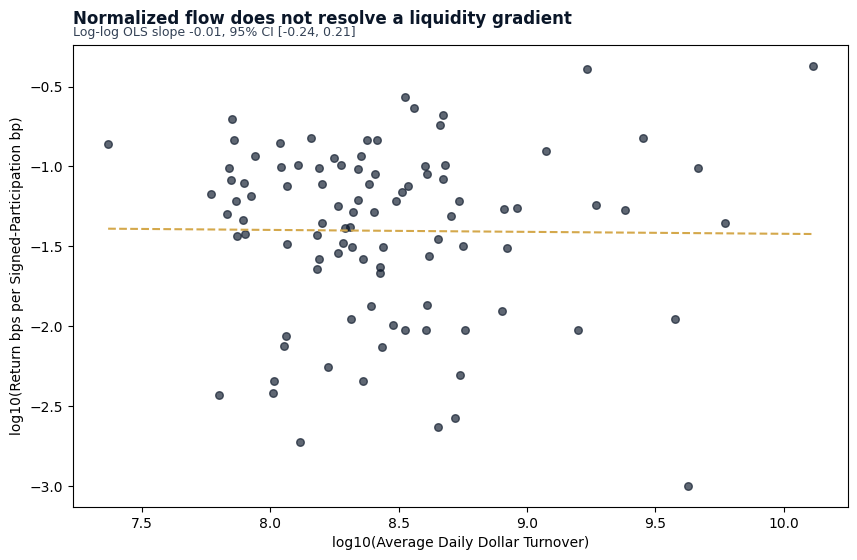

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(log_adv, log_lambda, color=COLORS["blue"], alpha=0.65, s=30)
ax.set_xlabel("log10(Average Daily Dollar Turnover)")
ax.set_ylabel("log10(Return bps per Signed-Participation bp)")
if cross_section_resolved:
    x_line = np.linspace(log_adv.min(), log_adv.max(), 100)
    ax.plot(x_line, intercept + slope * x_line, color=COLORS["amber"], linestyle="--")
    if slope_low <= 0 <= slope_high:
        slope_message = "Normalized flow does not resolve a liquidity gradient"
    else:
        direction = "falls" if slope < 0 else "rises"
        slope_message = f"Normalized flow association {direction} with dollar liquidity"
    subtitle = f"Log-log OLS slope {slope:.2f}, 95% CI [{slope_low:.2f}, {slope_high:.2f}]"
else:
    slope_message = "This sample is too thin to resolve a liquidity gradient"
    subtitle = cross_section_note
add_message_title(ax, slope_message, subtitle=subtitle)
fig.show()

In [25]:
if cross_section_resolved:
    interval_reading = "excludes zero" if slope_low * slope_high > 0 else "includes zero"
    cross_section_reading = (
        f"**Cross-sectional reading:** The slope is {slope:.2f} with a 95% interval from "
        f"{slope_low:.2f} to {slope_high:.2f}; the interval {interval_reading}. The regression "
        f"R-squared is {r_squared_cross:.3f}. This is descriptive evidence for the selected "
        "late-2021 sample, not a universal liquidity law."
    )
else:
    cross_section_reading = (
        f"**Cross-sectional reading:** not available on this sample - {cross_section_note}. "
        "The scatter above is still the evidence the fit would have used; what is missing is "
        "enough of it to estimate a slope whose interval means anything."
    )
display(Markdown(cross_section_reading))

**Cross-sectional reading:** The slope is -0.01 with a 95% interval from -0.24 to 0.21; the interval includes zero. The regression R-squared is 0.000. This is descriptive evidence for the selected late-2021 sample, not a universal liquidity law.

## 4. A Representative Symbol

A central symbol shows how noisy the minute-level relation remains. The plot clips both axes to
their central 99% solely for visibility; the Huber fit above used every valid observation.

In [26]:
rep_symbol = (
    lambda_df.with_columns(distance=(pl.col("lambda_participation") - median_lambda).abs())
    .sort("distance")
    .item(0, "symbol")
)
rep_row = lambda_df.filter(pl.col("symbol") == rep_symbol).row(0, named=True)
rep_data = nq_flow.filter(pl.col("symbol") == rep_symbol).with_columns(
    signed_participation_bps=pl.col("signed_volume") / rep_row["adv_shares"] * 10_000
)
x = rep_data["signed_participation_bps"].to_numpy()
y = rep_data["price_return_bps"].to_numpy()
x_low, x_high = np.quantile(x, [0.005, 0.995])
y_low, y_high = np.quantile(y, [0.005, 0.995])
central = np.flatnonzero((x >= x_low) & (x <= x_high) & (y >= y_low) & (y <= y_high))
if len(central) == 0:
    raise ValueError(f"No finite central observations available for {rep_symbol}.")
plot_idx = np.random.choice(central, min(5_000, len(central)), replace=False)

/tmp/ipykernel_1437927/341734669.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


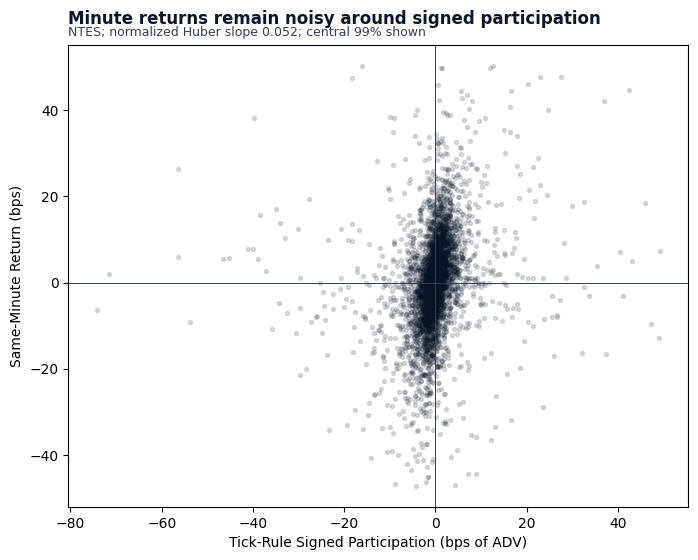

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x[plot_idx], y[plot_idx], color=COLORS["blue"], alpha=0.15, s=8)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.7)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.7)
ax.set_xlabel("Tick-Rule Signed Participation (bps of ADV)")
ax.set_ylabel("Same-Minute Return (bps)")
add_message_title(
    ax,
    "Minute returns remain noisy around signed participation",
    subtitle=(
        f"{rep_symbol}; normalized Huber slope {rep_row['lambda_participation']:.3f}; "
        "central 99% shown"
    ),
)
fig.show()

**Interpretation**: Normalization removes nominal price and share-scale differences. It does not
solve event ordering: the minute aggregate still measures association, and the dispersion warns
against using this coefficient as a bar-level predictor.

## 5. Intraday Volume Profile

The same regular-session sample reveals when market volume is available. A volume trough does not
by itself imply low impact: for a fixed order, lower $V$ raises $Q/V$. Spread, depth, urgency, and
adverse selection must be evaluated separately.

In [28]:
nq_volume_profile = (
    nq_micro.filter(pl.col("volume") > 0)
    .with_columns(
        minute_of_day=(
            pl.col("timestamp").dt.hour().cast(pl.Int32) * 60
            + pl.col("timestamp").dt.minute().cast(pl.Int32)
        ),
    )
    .group_by("minute_of_day")
    .agg(
        mean_volume=pl.col("volume").mean(),
        median_volume=pl.col("volume").median(),
    )
    .sort("minute_of_day")
)

trading_hours = nq_volume_profile.filter(
    (pl.col("minute_of_day") >= 570) & (pl.col("minute_of_day") < 960)
)
if trading_hours.is_empty():
    raise ValueError("No intraday volume profile available for the selected NASDAQ-100 sample.")

total_vol = trading_hours["mean_volume"].sum()
trading_hours = trading_hours.with_columns(
    vol_fraction=pl.col("mean_volume") / total_vol,
    time_label=(
        (pl.col("minute_of_day") // 60).cast(pl.String)
        + ":"
        + (pl.col("minute_of_day") % 60).cast(pl.String).str.zfill(2)
    ),
)

open_share = float(
    trading_hours.filter(pl.col("minute_of_day").is_between(570, 599))["vol_fraction"].sum()
)
close_share = float(
    trading_hours.filter(pl.col("minute_of_day").is_between(930, 959))["vol_fraction"].sum()
)
boundary_share = open_share + close_share

/tmp/ipykernel_1437927/2561855552.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


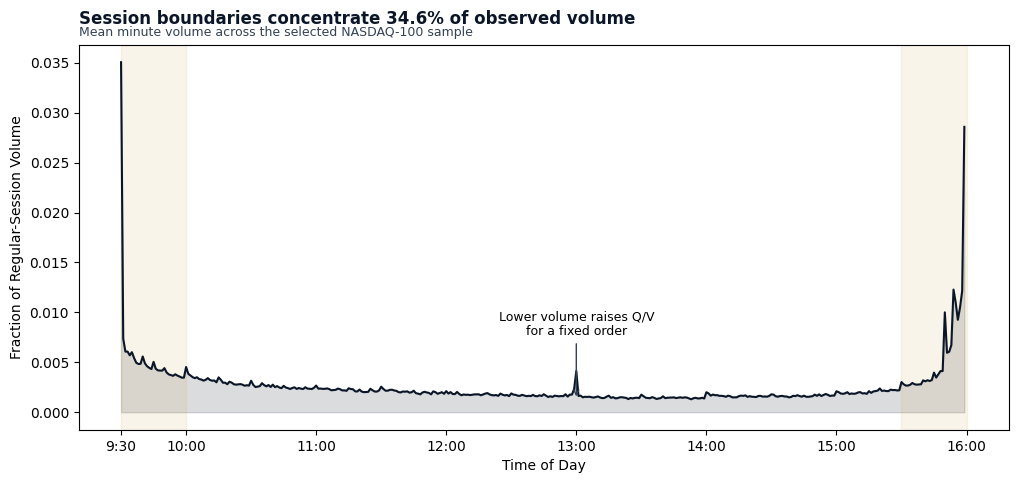

In [29]:
th_pd = trading_hours.to_pandas()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(th_pd["minute_of_day"], th_pd["vol_fraction"], color=COLORS["blue"], alpha=0.15)
ax.plot(th_pd["minute_of_day"], th_pd["vol_fraction"], color=COLORS["blue"], linewidth=1.5)
ax.axvspan(570, 600, color=COLORS["amber"], alpha=0.12)
ax.axvspan(930, 960, color=COLORS["amber"], alpha=0.12)
ax.set(xlabel="Time of Day", ylabel="Fraction of Regular-Session Volume")
add_message_title(
    ax,
    f"Session boundaries concentrate {boundary_share:.1%} of observed volume",
    subtitle="Mean minute volume across the selected NASDAQ-100 sample",
)

tick_times = [570, 600, 660, 720, 780, 840, 900, 960]
ax.set_xticks(tick_times, [f"{minute // 60}:{minute % 60:02d}" for minute in tick_times])

midday_idx = th_pd.loc[th_pd["minute_of_day"].between(700, 840), "vol_fraction"]
if len(midday_idx) > 0:
    ax.annotate(
        "Lower volume raises Q/V\nfor a fixed order",
        xy=(780, midday_idx.min()),
        xytext=(780, th_pd["vol_fraction"].max() * 0.22),
        arrowprops={"arrowstyle": "->", "color": COLORS["neutral"]},
        fontsize=9,
        ha="center",
    )

fig.show()

In [30]:
display(
    Markdown(
        f"**Volume reading:** The first 30 minutes contribute {open_share:.1%} and the last "
        f"30 minutes contribute {close_share:.1%} of the mean regular-session profile. The "
        "midday trough raises participation-driven impact for a fixed order; whether midday is "
        "cheaper overall also depends on spreads, depth, urgency, and adverse selection."
    )
)

**Volume reading:** The first 30 minutes contribute 17.0% and the last 30 minutes contribute 17.6% of the mean regular-session profile. The midday trough raises participation-driven impact for a fixed order; whether midday is cheaper overall also depends on spreads, depth, urgency, and adverse selection.

## 6. Bounded Capacity Scenarios

Capacity is conditional on a gross-alpha budget, turnover, execution approach, and valid dollar
liquidity. We exclude ETF and FX panels because their available fields do not support historical
dollar turnover. The supported scenario assumes trades are distributed in proportion to each
selected instrument's average dollar volume.

In [31]:
capacity_markets = ["Crypto Perps", "CME Futures", "S&P 500 Equities", "NASDAQ-100"]
capacity_rows = []
for name in capacity_markets:
    df = daily_stats[name]
    entity_col = entity_cols[name]
    per_entity = (
        df.filter(pl.col("daily_turnover_usd").is_not_null())
        .group_by(entity_col)
        .agg(mean_daily_turnover_usd=pl.col("daily_turnover_usd").mean())
    )
    capacity_rows.append(
        {
            "market": name,
            "entities": len(per_entity),
            "total_addv_usd": float(per_entity["mean_daily_turnover_usd"].sum()),
            "median_daily_sigma": float(df["sigma"].drop_nulls().median()),
            "eta_assumption": LITERATURE_ETA[name],
        }
    )

capacity_df = pl.DataFrame(capacity_rows)
capacity_df

market,entities,total_addv_usd,median_daily_sigma,eta_assumption
str,i64,f64,f64,f64
"""Crypto Perps""",19,2.8901e10,0.044091,0.3
"""CME Futures""",30,8.4908e11,0.009335,0.08
"""S&P 500 Equities""",50,7.4444e10,0.017563,0.15
"""NASDAQ-100""",50,5.8491e10,0.018579,0.12


In [32]:
unsupported_capacity = pl.DataFrame(
    {
        "market": ["ETFs", "FX Pairs"],
        "reason_excluded": [
            "Adjusted prices cannot be paired with observed shares for historical USD turnover",
            "OANDA volume is tick activity, not traded currency or dollar notional",
        ],
    }
)
unsupported_capacity

market,reason_excluded
str,str
"""ETFs""","""Adjusted prices cannot be pair…"
"""FX Pairs""","""OANDA volume is tick activity,…"


### Scenario Bounds

The participation ceiling is a declared validity guard, not an estimated optimum. Net alpha is
shown only while the scenario order remains at or below 20% of the selected universe's ADDV.

In [33]:
capacity_summary_rows = []
for row in capacity_df.iter_rows(named=True):
    max_aum = row["total_addv_usd"] * MAX_FEASIBLE_PARTICIPATION / TURNOVER_PER_REBALANCE
    zero_participation = (
        GROSS_ALPHA_BPS / (row["median_daily_sigma"] * row["eta_assumption"] * 10_000)
    ) ** 2
    break_even_aum = (
        zero_participation * row["total_addv_usd"] / TURNOVER_PER_REBALANCE
        if zero_participation <= MAX_FEASIBLE_PARTICIPATION
        else None
    )
    capacity_summary_rows.append(
        {
            **row,
            "max_aum_at_participation_bound": max_aum,
            "break_even_aum_within_bound": break_even_aum,
        }
    )

capacity_summary = pl.DataFrame(capacity_summary_rows)
capacity_summary

market,entities,total_addv_usd,median_daily_sigma,eta_assumption,max_aum_at_participation_bound,break_even_aum_within_bound
str,i64,f64,f64,f64,f64,f64
"""Crypto Perps""",19,2.8901e10,0.044091,0.3,1.9268e10,1.3766e10
"""CME Futures""",30,8.4908e11,0.009335,0.08,5.6605e11,null
"""S&P 500 Equities""",50,7.4444e10,0.017563,0.15,4.9630e10,null
"""NASDAQ-100""",50,5.8491e10,0.018579,0.12,3.8994e10,null


### Capacity-Curve Helper

In [34]:
def capacity_curve(row: dict, aum_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return participation and bounded net alpha for one scenario row."""
    participation = aum_grid * TURNOVER_PER_REBALANCE / row["total_addv_usd"]
    feasible = participation <= MAX_FEASIBLE_PARTICIPATION
    impact_bps = row["median_daily_sigma"] * row["eta_assumption"] * np.sqrt(participation) * 10_000
    return participation, np.where(feasible, GROSS_ALPHA_BPS - impact_bps, np.nan)

/tmp/ipykernel_1437927/143454103.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


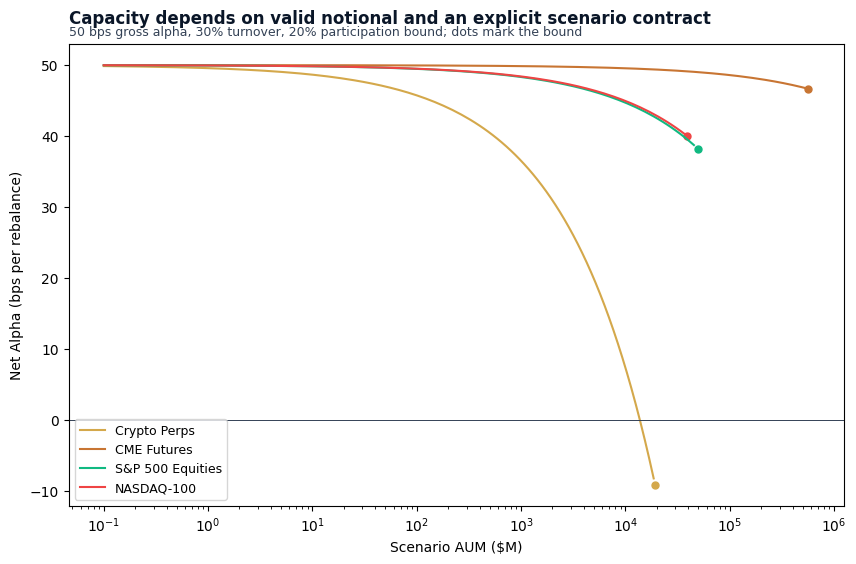

In [35]:
max_scenario_aum = float(capacity_summary["max_aum_at_participation_bound"].max())
aum_range = np.logspace(5, np.log10(max_scenario_aum * 1.15), 160)

fig, ax = plt.subplots(figsize=(10, 6))
for row in capacity_summary.iter_rows(named=True):
    participation, net_alpha = capacity_curve(row, aum_range)
    color = market_colors[row["market"]]
    ax.plot(aum_range / 1e6, net_alpha, color=color, label=row["market"])
    endpoint_net = GROSS_ALPHA_BPS - (
        row["median_daily_sigma"]
        * row["eta_assumption"]
        * np.sqrt(MAX_FEASIBLE_PARTICIPATION)
        * 10_000
    )
    ax.scatter(
        row["max_aum_at_participation_bound"] / 1e6,
        endpoint_net,
        color=color,
        s=25,
    )

ax.axhline(0, color=COLORS["neutral"], linewidth=0.7)
ax.set_xscale("log")
ax.set_xlabel("Scenario AUM ($M)")
ax.set_ylabel("Net Alpha (bps per rebalance)")
add_message_title(
    ax,
    "Capacity depends on valid notional and an explicit scenario contract",
    subtitle="50 bps gross alpha, 30% turnover, 20% participation bound; dots mark the bound",
)
ax.legend(loc="lower left", fontsize=9)
fig.show()

In [36]:
display(
    Markdown(
        "**Capacity reading:** The curves are conditional scenarios for four supported panels, "
        "not asset-class limits. Their endpoints mark the declared participation bound. ETF and "
        "FX capacity remain unreported because the available fields do not support historical "
        "dollar turnover."
    )
)

**Capacity reading:** The curves are conditional scenarios for four supported panels, not asset-class limits. Their endpoints mark the declared participation bound. ETF and FX capacity remain unreported because the available fields do not support historical dollar turnover.

## 7. Normalize Before Comparing Model Shapes

Linear and square-root coefficients are not interchangeable. To isolate shape, both ETF models
are matched to the same impact at a 1% reference participation. Away from that point, only the
functional form differs. `NoImpact` remains a frictionless lower bound.

In [37]:
etf_scenario = scenario_df.filter(pl.col("market") == "ETFs").row(0, named=True)
participation_grid = np.logspace(-3, -1, 120)
sqrt_impact = (
    etf_scenario["median_daily_sigma"]
    * etf_scenario["eta_assumption"]
    * np.sqrt(participation_grid)
)
reference_impact = (
    etf_scenario["median_daily_sigma"]
    * etf_scenario["eta_assumption"]
    * np.sqrt(MODEL_REFERENCE_PARTICIPATION)
)
linear_coefficient = reference_impact / MODEL_REFERENCE_PARTICIPATION
linear_impact = linear_coefficient * participation_grid

/tmp/ipykernel_1437927/221222043.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


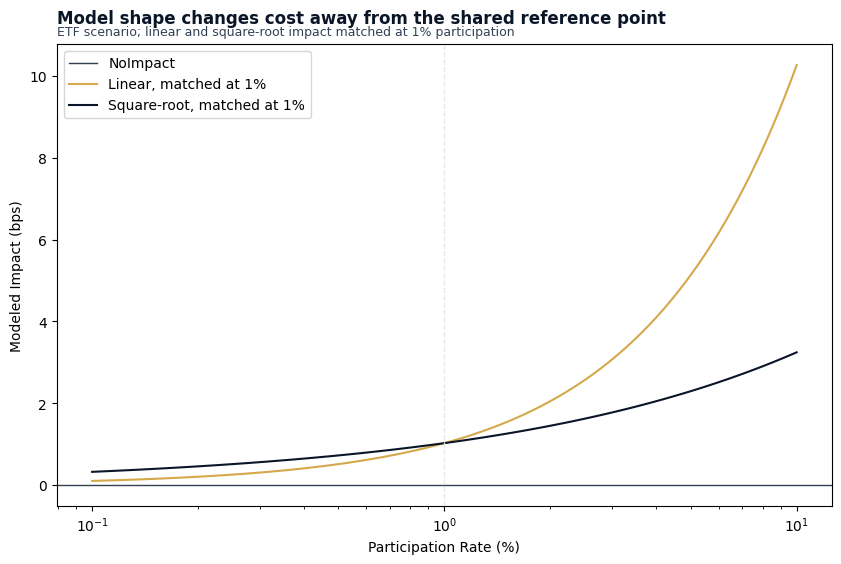

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(0, color=COLORS["neutral"], linewidth=1.0, label="NoImpact")
ax.plot(
    participation_grid * 100,
    linear_impact * 10_000,
    color=COLORS["amber"],
    label="Linear, matched at 1%",
)
ax.plot(
    participation_grid * 100,
    sqrt_impact * 10_000,
    color=COLORS["blue"],
    label="Square-root, matched at 1%",
)
ax.axvline(1, color=COLORS["silver_muted"], linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("Participation Rate (%)")
ax.set_ylabel("Modeled Impact (bps)")
add_message_title(
    ax,
    "Model shape changes cost away from the shared reference point",
    subtitle="ETF scenario; linear and square-root impact matched at 1% participation",
)
ax.legend()
fig.show()

In [39]:
display(
    Markdown(
        f"**Shape reading:** Both models equal {reference_impact * 10_000:.2f} bps at 1%. "
        f"At {participation_grid[0]:.1%}, linear impact is {linear_impact[0] * 10_000:.2f} "
        f"bps and square-root impact is {sqrt_impact[0] * 10_000:.2f} bps; at "
        f"{participation_grid[-1]:.0%}, they are {linear_impact[-1] * 10_000:.2f} and "
        f"{sqrt_impact[-1] * 10_000:.2f} bps. Matching the reference separates shape from "
        "coefficient scale."
    )
)

**Shape reading:** Both models equal 1.03 bps at 1%. At 0.1%, linear impact is 0.10 bps and square-root impact is 0.32 bps; at 10%, they are 10.27 and 3.25 bps. Matching the reference separates shape from coefficient scale.

## 8. VIX Buckets Change Sigma, Not Eta

In the square-root model $I = \sigma \cdot \eta \cdot \sqrt{Q/V}$, impact
rises during stressed markets because realized volatility $\sigma$ rises.
The VIX buckets below use full-sample quartiles as a retrospective diagnostic.
We hold $\eta_{\text{base}}$ fixed at its ETF literature value and only let
realized volatility vary across buckets.

In [40]:
# Load VIX
macro = load_macro(series=["vixcls"])
vix = (
    macro.select(
        pl.col("timestamp").cast(pl.Date),
        pl.col("vixcls").alias("vix"),
    )
    .filter(pl.col("vix").is_not_null())
    .sort("timestamp")
)

vix_q25, vix_q50, vix_q75 = (
    vix["vix"].quantile(0.25),
    vix["vix"].quantile(0.5),
    vix["vix"].quantile(0.75),
)

In [41]:
# Hold eta fixed and summarize the volatility channel for ETFs.
etf_vix = (
    daily_stats["ETFs"]
    .join(vix, on="timestamp", how="inner")
    .with_columns(
        vix_regime=pl.when(pl.col("vix") < vix_q25)
        .then(pl.lit("Q1 (Low)"))
        .when(pl.col("vix") < vix_q50)
        .then(pl.lit("Q2"))
        .when(pl.col("vix") < vix_q75)
        .then(pl.lit("Q3"))
        .otherwise(pl.lit("Q4 (High)")),
    )
)

eta_base = LITERATURE_ETA["ETFs"]

### Regime-Specific Impact Helper

In [42]:
def regime_impact_row(regime: str) -> dict:
    """Summarize modeled 1% participation impact for one VIX bucket."""
    subset = etf_vix.filter(
        (pl.col("vix_regime") == regime)
        & pl.col("ret").is_not_null()
        & pl.col("sigma").is_not_null()
        & (pl.col("sigma") > 0)
    )
    med_sigma = subset["sigma"].median()
    if med_sigma is None:
        return {
            "regime": regime,
            "median_daily_sigma": np.nan,
            "impact_1pct_bps": np.nan,
            "observations": len(subset),
        }
    impact_1pct = med_sigma * eta_base * np.sqrt(0.01) * 10_000
    return {
        "regime": regime,
        "median_daily_sigma": med_sigma,
        "impact_1pct_bps": impact_1pct,
        "observations": len(subset),
    }

In [43]:
regimes = ["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
regime_df = pl.DataFrame([regime_impact_row(regime) for regime in regimes])
if (
    regime_df["impact_1pct_bps"].null_count()
    or not np.isfinite(regime_df["impact_1pct_bps"].to_numpy()).all()
):
    raise ValueError("Every VIX bucket needs a finite modeled impact estimate")

regime_df

regime,median_daily_sigma,impact_1pct_bps,observations
str,f64,f64,i64
"""Q1 (Low)""",0.007682,0.76823,62516
"""Q2""",0.009244,0.924439,64799
"""Q3""",0.01132,1.131977,55779
"""Q4 (High)""",0.016617,1.661688,52172


The calculation does not estimate a new impact coefficient for each bucket.
It isolates the modeled volatility channel by holding $\eta$ and participation
fixed while changing only the bucket-level median $\sigma$.

/tmp/ipykernel_1437927/3281021408.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


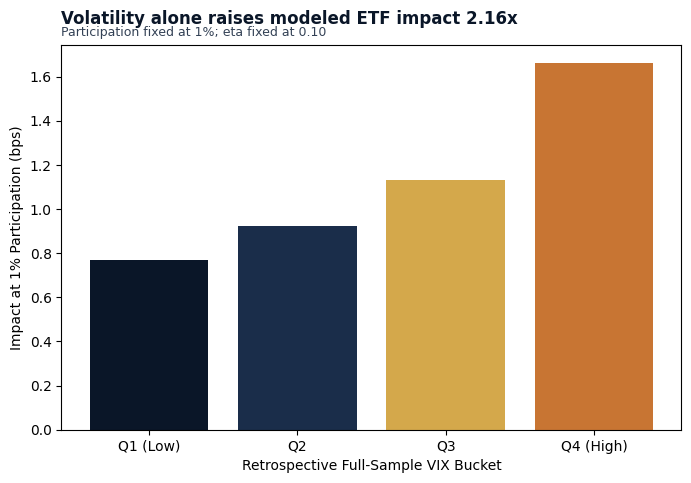

In [44]:
impacts = regime_df["impact_1pct_bps"].to_numpy()
impact_ratio = impacts[-1] / impacts[0]

fig, ax = plt.subplots(figsize=(8, 5))
colors = [COLORS["blue"], COLORS["slate"], COLORS["amber"], COLORS["copper"]]
ax.bar(regimes, impacts, color=colors)
ax.set_ylabel("Impact at 1% Participation (bps)")
ax.set_xlabel("Retrospective Full-Sample VIX Bucket")
add_message_title(
    ax,
    f"Volatility alone raises modeled ETF impact {impact_ratio:.2f}x",
    subtitle=f"Participation fixed at 1%; eta fixed at {eta_base:.2f}",
)

fig.show()

In [45]:
display(
    Markdown(
        f"**Retrospective reading:** With eta fixed at {eta_base:.2f}, the modeled "
        f"1% participation impact rises from {impacts[0]:.2f} bps in Q1 to "
        f"{impacts[-1]:.2f} bps in Q4, a {impact_ratio:.2f}x ratio. This is a "
        "volatility-scenario result, not evidence that eta itself changes with VIX. "
        "A deployable regime rule would need thresholds estimated only from prior data."
    )
)

**Retrospective reading:** With eta fixed at 0.10, the modeled 1% participation impact rises from 0.77 bps in Q1 to 1.66 bps in Q4, a 2.16x ratio. This is a volatility-scenario result, not evidence that eta itself changes with VIX. A deployable regime rule would need thresholds estimated only from prior data.

## Key Takeaways

In [46]:
low_scenario = scenario_df.sort("impact_1pct_bps").row(0, named=True)
high_scenario = scenario_df.sort("impact_1pct_bps").row(-1, named=True)
display(
    Markdown(
        "\n".join(
            [
                "1. **The square-root curves are scenarios, not calibrations.** "
                f"At 1% participation they span {low_scenario['impact_1pct_bps']:.2f} bps "
                f"for {low_scenario['market']} to {high_scenario['impact_1pct_bps']:.2f} bps "
                f"for {high_scenario['market']}, using stated literature eta assumptions.",
                "",
                (
                    "2. **Normalized signed-flow estimates support a descriptive liquidity "
                    "comparison.** The cross-sectional log slope is "
                    f"{slope:.2f} with a 95% interval from {slope_low:.2f} to "
                    f"{slope_high:.2f}; same-minute returns and tick-rule signs do not "
                    "identify causal permanent impact."
                )
                if cross_section_resolved
                else (
                    "2. **The cross-sectional comparison is not available on this sample.** "
                    f"{cross_section_note}, so no slope is reported. Same-minute returns and "
                    "tick-rule signs would not have identified causal permanent impact in any "
                    "case."
                ),
                "",
                "3. **Regular-session activity is concentrated near the boundaries.** "
                f"The first and final 30 minutes contain {boundary_share:.1%} of the "
                "sample's regular-session volume. Lower midday volume means a fixed order "
                "raises participation unless execution is slowed.",
                "",
                "4. **USD capacity requires USD turnover.** The capacity exercise covers "
                "Crypto, CME Futures, S&P 500, and NASDAQ 100. ETF share volume and FX tick "
                "volume are excluded rather than mixed into a dollar comparison.",
                "",
                "5. **The VIX comparison holds eta fixed.** Moving from the retrospective "
                f"Q1 to Q4 volatility bucket raises modeled ETF impact {impact_ratio:.2f}x "
                "through sigma alone.",
                "",
                "**Next:** See `04_vwap_twap_execution` for execution algorithms that "
                "balance impact and timing risk.",
                "",
                "**Book:** Chapter 18.4 covers market impact theory and its connection to "
                "optimal execution.",
            ]
        )
    )
)

1. **The square-root curves are scenarios, not calibrations.** At 1% participation they span 0.24 bps for FX Pairs to 13.24 bps for Crypto Perps, using stated literature eta assumptions.

2. **Normalized signed-flow estimates support a descriptive liquidity comparison.** The cross-sectional log slope is -0.01 with a 95% interval from -0.24 to 0.21; same-minute returns and tick-rule signs do not identify causal permanent impact.

3. **Regular-session activity is concentrated near the boundaries.** The first and final 30 minutes contain 34.6% of the sample's regular-session volume. Lower midday volume means a fixed order raises participation unless execution is slowed.

4. **USD capacity requires USD turnover.** The capacity exercise covers Crypto, CME Futures, S&P 500, and NASDAQ 100. ETF share volume and FX tick volume are excluded rather than mixed into a dollar comparison.

5. **The VIX comparison holds eta fixed.** Moving from the retrospective Q1 to Q4 volatility bucket raises modeled ETF impact 2.16x through sigma alone.

**Next:** See `04_vwap_twap_execution` for execution algorithms that balance impact and timing risk.

**Book:** Chapter 18.4 covers market impact theory and its connection to optimal execution.